# Surrogates of a Load Path

A surrogate of what the solver *produced*, not of an objective computed from it.

The structure is the 270 degree deep circular arch of

> Bouwer, J. M., Kok, S. and Wilke, D. N. (2023). *Challenges and solutions to arc-length
> controlled structural shape design problems.* Mechanics Based Design of Structures and
> Machines, **51**(7), 4088-4119.
> [doi:10.1080/15397734.2021.1950549](https://doi.org/10.1080/15397734.2021.1950549)

and the surrogates are those of

> Bouwer, J., Wilke, D. N. and Kok, S. (2024). *A novel and fully automated coordinate system
> transformation scheme for near optimal surrogate construction.* Computer Methods in Applied
> Mechanics and Engineering, **419**, 116648.
> [doi:10.1016/j.cma.2023.116648](https://doi.org/10.1016/j.cma.2023.116648)

**One shape variable, four solves.** The arch's radius profile is a single design radius, and
the two responses are the crown load factor and the crown displacement, each fitted as a
function of that radius **and the accumulated arc length**. Arc length being an input is the
whole point: a stored path is not one sample but one sample per arc step, and the pair of
fitted surfaces then describes a continuous family of load paths.

Modelling the responses rather than an objective is the standard way round, and it is worth
being explicit about why. An objective is a small calculation on top of these two surfaces.
Change it - reweight the load against the displacement, match a different target, add a
constraint - and the surfaces are still valid, because nothing about them knew what question
was going to be asked. A surrogate fitted to the objective has to be rebuilt from new
simulations every time the question changes.

Sections 1 to 5 use **one** shape variable and four solves, because two dimensions of input is
the largest that can honestly be *drawn* and the surfaces are worth seeing. Section 6 then
takes the same machinery to **three** variables and fifteen curves, where nothing can be
plotted as a surface and accuracy has to be shown by holding designs back and overlaying
predicted load paths on solved ones.

> Needs the optional `ge_rbf` dependency: `uv sync --extra surrogate`.
>
> **A full re-run takes about 15 minutes**, nearly all of it the twenty-three arc-length
> solves carrying sensitivities. The notebook is committed with its output, so it reads
> without being executed.

In [1]:
import contextlib
import logging
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

from fem2d.meshers import Q8Mesh
from fem2d.solvers import ArcLengthSolver
from fem2d.surrogate import PathSurrogate

logging.basicConfig(level=logging.INFO, format='%(message)s', stream=sys.stdout)
SolverLog = logging.getLogger('fem2d.solvers')


@contextlib.contextmanager
def quiet():
    # The solvers log every iteration; silence them for the sweeps.
    SolverLog.setLevel(logging.WARNING)
    try:
        yield
    finally:
        SolverLog.setLevel(logging.NOTSET)

## 1. A one-variable arch

Same structure and material as
[`ArcLengthControlledShapeDesign.ipynb`](ArcLengthControlledShapeDesign.ipynb), but the shape
is a **single** design radius rather than four. The radius profile runs through three points -
the two ends, pinned at 100 mm, and the one design radius at the crown - so `_RadiusSpline`
drops from a cubic to a quadratic, which it does deliberately for exactly this case.

The design box is **[96, 120] mm**, narrower than the paper's `[80, 120]`, and that is a
judgement worth stating. With one variable the whole arch moves with that radius, and below
about 92 mm the response stops being something four samples could represent: the peak load
factor runs 460, **764**, 643, 322 at radii 80, 84, 88, 92, turning over sharply, and then
declines smoothly and monotonically above 92. Four samples can cover the smooth region or
misrepresent the sharp one. Isolated designs in the box also cannot be traced at all - 106 mm
is one - which is the same behaviour the four-variable notebook reports.

In [2]:
h = 12**0.5
E = 210000.0                   # 210 GPa, in N and mm
v, t, plane = 0.3, 1.0, 0      # plane stress: a beam of unit width
R = 100.0                      # radius at the two pinned ends
Span = 270.0                   # the paper's arch, -45 to 225 degrees
Load = -1.0                    # unit point load at the crown, scaled by the load factor

ElNum, ArcStep, ArcTotal = 20, 200.0, 2600.0

Box = [(96.0, 120.0)]                             # the design box, one variable
Designs = np.array([96.0, 104.0, 112.0, 120.0])   # the four solves
HeldOut = 100.0                                   # never sampled; section 5 checks against it


def Arch(radii):
    # One radius or several: the mesher runs a spline through the design radii and the two
    # pinned ends, so section 6 reuses this unchanged with three.
    m = Q8Mesh(E, v, t, plane, 'Q8')
    m.SemiCircularArch(ElNum, R, [float(r) for r in np.atleast_1d(radii)], h, Load, Span=Span)
    return m


print(f'{Arch(100.0).VariableNumber} design variable for sections 1 to 5, '
      f'{Arch([100.0]*3).VariableNumber} for section 6')

1 design variable for sections 1 to 5, 3 for section 6


## 2. Four solves, and what each one yields

`Curve` returns everything the surrogate needs from one trace. Two of the five arrays are new:
`dLds` and `dUds_All`, the derivatives of the load factor and the displacement with respect to
**arc length**, which `ArcLengthSolver` now returns alongside the design sensitivities.

They are needed because arc length is an input to the surrogate, and a gradient-enhanced fit
wants a derivative in every input direction. They cost nothing: the solver already forms
`K_T⁻¹F` at each converged point to get the design sensitivities, and the path tangent falls
straight out of it. Differentiating the arc-length constraint along the path gives
`ds² = |dU|² + ψ²dλ²` with `dU = dUdL·dλ`, so

$$\frac{d\lambda}{ds} = \frac{\pm 1}{\sqrt{dUdL \cdot dUdL + \psi^2}}, \qquad
\frac{dU}{ds} = dUdL \, \frac{d\lambda}{ds}$$

Two properties make that self-checking, and both are asserted below: with `ψ = 0` the path has
**unit speed**, `|dU/ds| = 1` exactly, and at a **limit point** the tangent stiffness is
singular so `dUdL` blows up and `dλ/ds` passes through zero.

In [3]:
def Curve(radii):
    """Trace one design and return its path, parametrised by accumulated arc length."""
    m = Arch(radii)
    with quiet():
        ArcLengthSolver(m, ArcLength=ArcStep, TotalArcLength=ArcTotal,
                        tol=1e-6, MaxIter=9, Sensitivity=True).Solve()

    # Row 0 of the stored path is the undeformed state, which carries no sensitivity, so
    # every array below is taken from step 1 on.
    s = m.ArcValues[1:]                             # accumulated arc length
    lam = np.ravel(m.LoadValues)[1:]                # load factor
    u = m.AllU[m.LoadNode, 1:]                      # crown displacement

    dLamdx = np.atleast_2d(m.dLdx)                  # (steps, variables)
    dUdx = np.atleast_3d(m.dUdx_All)[m.LoadNode, :, :].T

    dLamds = np.ravel(m.dLds)                       # (steps,)
    dUds = m.dUds_All[m.LoadNode, :]

    return dict(s=s, lam=lam, u=u, dLamdx=dLamdx, dUdx=dUdx, dLamds=dLamds, dUds=dUds,
                Speed=np.linalg.norm(m.dUds_All, axis=0))


Paths = {}
Clock = time.perf_counter()
for Radius in Designs:
    Paths[Radius] = Curve(Radius)
Elapsed = time.perf_counter() - Clock

print(f'{len(Paths)} designs traced in {Elapsed/60:.1f} min')
print()
print(f"{'radius':>8}{'steps':>7}{'arc length':>12}{'peak lambda':>13}{'|dU/ds| - 1':>14}")
for Radius, Path in Paths.items():
    print(f'{Radius:>8.1f}{Path["s"].size:>7}{Path["s"][-1]:>12.1f}'
          f'{Path["lam"].max():>13.1f}{np.max(np.abs(Path["Speed"] - 1)):>14.2e}')

print()
print('the last column is the unit-speed identity: with psi = 0 arc length IS distance')
print('travelled in displacement space, so the path tangent has to be a unit vector')

4 designs traced in 2.0 min

  radius  steps  arc length  peak lambda   |dU/ds| - 1
    96.0     19      2660.7        299.9      2.22e-16
   104.0     18      2665.7        261.3      5.55e-16
   112.0     17      2648.5        226.9      2.22e-16
   120.0     16      2731.4        202.1      4.44e-16

the last column is the unit-speed identity: with psi = 0 arc length IS distance
travelled in displacement space, so the path tangent has to be a unit vector


In [4]:
# The other identity: dlambda/ds passes through zero exactly where the load factor peaks.
Radius = Designs[0]
Path = Paths[Radius]
Peak = int(np.argmax(Path['lam']))

print(f'radius {Radius}, load factor peaks at step {Peak + 1} of {Path["s"].size}')
print()
print(f"{'step':>6}{'arc length':>12}{'lambda':>10}{'dlambda/ds':>14}")
for k in range(max(0, Peak - 2), min(Path['s'].size, Peak + 3)):
    Mark = '   <- peak' if k == Peak else ''
    print(f'{k+1:>6}{Path["s"][k]:>12.1f}{Path["lam"][k]:>10.2f}'
          f'{Path["dLamds"][k]:>14.6f}{Mark}')

print()
print('the sign change is the limit point: past it the arch sheds load as it keeps deforming,')
print('and a load-controlled solver would have fallen off the path here')

radius 96.0, load factor peaks at step 6 of 19

  step  arc length    lambda    dlambda/ds
     4       741.4    270.26      0.157362
     5       941.4    295.32      0.084509
     6      1141.4    299.91     -0.050218   <- peak
     7      1341.4    271.55     -0.235638
     8      1482.8    229.16     -0.356913

the sign change is the limit point: past it the arch sheds load as it keeps deforming,
and a load-controlled solver would have fallen off the path here


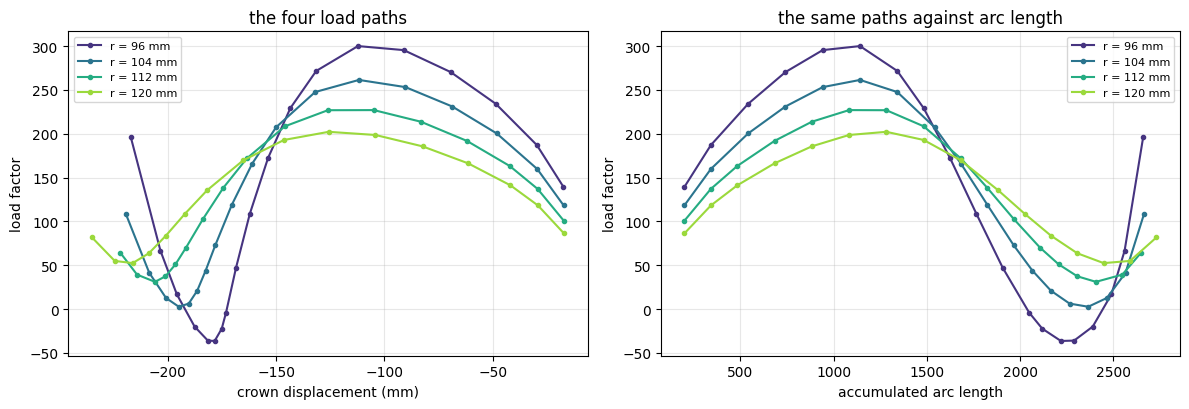

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))

Colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(Designs)))

for Colour, (Radius, Path) in zip(Colours, Paths.items(), strict=True):
    a1.plot(Path['u'], Path['lam'], 'o-', ms=3, color=Colour, label=f'r = {Radius:.0f} mm')
    a2.plot(Path['s'], Path['lam'], 'o-', ms=3, color=Colour, label=f'r = {Radius:.0f} mm')

a1.set(xlabel='crown displacement (mm)', ylabel='load factor',
       title='the four load paths')
a2.set(xlabel='accumulated arc length', ylabel='load factor',
       title='the same paths against arc length')
for Axis in (a1, a2):
    Axis.legend(fontsize=8)
    Axis.grid(alpha=0.3)
plt.tight_layout()

## 3. Stacking the paths into samples, and stretching the arc-length axis

Each stored point becomes one row of `(radius, arc length)` with a value and a gradient in
both directions. Four solves give around seventy rows, not four.

Then the scaling, which is the part that decides whether this works at all. `ge-lhm` estimates
each local Hessian from `n + 1` neighbours, which in two dimensions is exactly three, so if
those three sit on one path they are collinear and the curvature across designs is estimated
from nothing at all.

The obvious pre-processing — normalise every axis to `[0, 1]` — is what *causes* that. It puts
the designs `1/3` apart in radius while consecutive points on one path are about `1/17` apart
in arc length, so every point's nearest neighbours become the points immediately before and
after it on its own path. The cell below counts all three coordinate choices.

`ge_rbf.TrajectoryScaler` fixes it by targeting a *ratio*: after scaling, one step along a
path is `stretch` times the distance between neighbouring designs. Because that is a ratio of
a design distance to an arc distance it is unit-free, so it does not matter whether the arc
axis started out finer or coarser than the design axis — here it started coarser, and
`scale_` comes out below one.

The gradients are rescaled by the same map on the way in and unwound on the way out.
`TrajectoryScaler` does that too, and it is worth knowing it fails quietly if skipped: the
values stay right and the fit is handed gradients belonging to a different coordinate system.

The basis here is left at one centre per sample, interpolating. Section 6 searches the centre
count instead, and switching that off at this size is a measured choice, not an oversight: with
only four trajectories a group-wise fold trains on three designs and validates on one, which is
far too little to judge a basis size from. It settles on 19 centres of 70 and the held-out load
factor error rises from 0.32% to 3.93%. The search needs designs to hold out before it can earn
its place.

In [6]:
# One row per stored path point, plus a label saying which path each row came from. The
# labels matter twice over: the scaler measures the spacing between trajectories with them,
# and the centre-count search holds whole trajectories out rather than scattered rows.
X = np.concatenate([np.full((Path['s'].size, 1), Radius) for Radius, Path in Paths.items()])
S = np.concatenate([Path['s'] for Path in Paths.values()])
Groups = np.concatenate([np.full(Path['s'].size, i)
                         for i, Path in enumerate(Paths.values())])

Lam = np.concatenate([Path['lam'] for Path in Paths.values()])
dLamdx = np.concatenate([Path['dLamdx'] for Path in Paths.values()])
dLamds = np.concatenate([Path['dLamds'] for Path in Paths.values()])

U = np.concatenate([Path['u'] for Path in Paths.values()])
dUdx = np.concatenate([Path['dUdx'] for Path in Paths.values()])
dUds = np.concatenate([Path['dUds'] for Path in Paths.values()])

print(f'{X.shape[0]} sample rows from {len(Paths)} solves, {X.shape[1]} shape variable')
print(f'each row carries a value and a gradient in {X.shape[1] + 1} input directions')

70 sample rows from 4 solves, 1 shape variable
each row carries a value and a gradient in 2 input directions


In [7]:
# One centre per sample here, interpolating. Section 6 searches the count instead, and the
# reason the search is switched off at this size is measured rather than assumed: with four
# trajectories a group-wise fold trains on three designs and validates on one, which is too
# little to judge a basis from. It picks 19 centres of 70 and the held-out load factor error
# goes from 0.32% to 3.93%. Fifteen trajectories is a different matter.
LamModel = PathSurrogate(Centres=None).Fit(X, S, Lam, dLamdx, dLamds, Groups=Groups)
UModel = PathSurrogate(Centres=None).Fit(X, S, U, dUdx, dUds, Groups=Groups)

Scaler = LamModel.Scaler_


def OwnPathShare(Z, Neighbours=3):
    '''Fraction of each point's nearest neighbours that lie on the same design's path.'''
    Distance = np.linalg.norm(Z[:, None, :] - Z[None, :, :], axis=-1)
    np.fill_diagonal(Distance, np.inf)
    Near = np.argsort(Distance, axis=1)[:, :Neighbours]
    Same = Groups[Near] == Groups[:, None]
    return Same.mean(), Same.all(axis=1).mean()


Block = np.column_stack((X, S))
Naive = np.column_stack(((X - X.min())/np.ptp(X), (S - S.min())/np.ptp(S)))

print(f'design spacing {Scaler.design_spacing_:.1f} mm, arc step {Scaler.step_spacing_:.0f}, '
      f'so scale_ = {Scaler.scale_:.4f}')
print()
print(f"{'coordinates':<26}{'neighbours on own path':>24}{'points with all three':>23}")
for Name, Z in (('raw, as solved', Block), ('normalised to [0, 1]', Naive),
                ('TrajectoryScaler', Scaler.transform(Block))):
    Share, All = OwnPathShare(Z)
    print(f'{Name:<26}{Share:>23.1%}{All:>23.1%}')

print()
print('the middle row is the failure mode, and it is the one worth dwelling on: normalising')
print('every axis to [0,1] is the obvious pre-processing and it is what CREATES the problem,')
print('stranding every local Hessian on three points in a line. The scaler targets the ratio')
print('directly, so it does not matter which way the raw coordinates started out.')
print()
for Name, Model in (('load factor', LamModel), ('displacement', UModel)):
    print(f'{Name:<14} frame {Model.Frame_.method_:<9} '
          f'{Model.Model_.centers_.shape[0]:>3} centres  '
          f'epsilon {Model.Search_.best_epsilon:.4g}  '
          f'condition {Model.Model_.condition_:.2e}')

design spacing 8.0 mm, arc step 150, so scale_ = 0.0799

coordinates                 neighbours on own path  points with all three
raw, as solved                               0.0%                   0.0%
normalised to [0, 1]                       100.0%                 100.0%
TrajectoryScaler                            40.0%                   0.0%

the middle row is the failure mode, and it is the one worth dwelling on: normalising
every axis to [0,1] is the obvious pre-processing and it is what CREATES the problem,
stranding every local Hessian on three points in a line. The scaler targets the ratio
directly, so it does not matter which way the raw coordinates started out.

load factor    frame ge-lhm     70 centres  epsilon 0.003763  condition 8.92e+12
displacement   frame ge-lhm     70 centres  epsilon 0.04994  condition 2.06e+12


## 4. The two surfaces

Both responses over the whole `(radius, arc length)` rectangle, with the four sampled paths
drawn on top. The sampled paths are the only places the solver was ever run; everything
between them is the surrogate.

The arc-length axis is drawn to the shortest path's extent, since past that the surfaces would
be extrapolating beyond every design that reached there.

red lines are the four solved paths; the surfaces are fitted from them


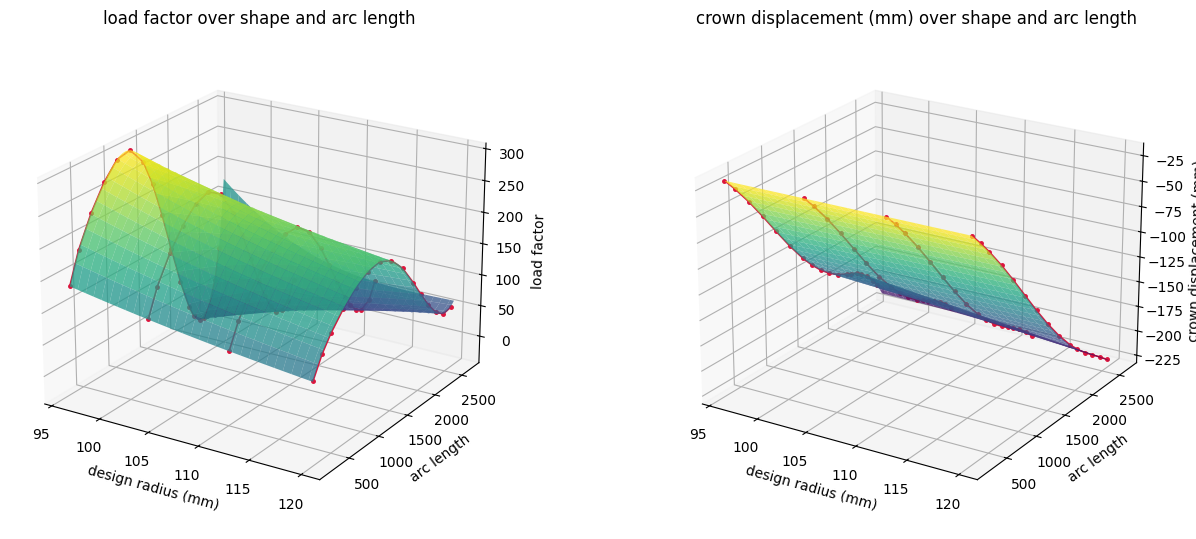

In [8]:
Reach = min(Path['s'][-1] for Path in Paths.values())
GridX = np.linspace(Box[0][0], Box[0][1], 60)
GridS = np.linspace(S.min(), Reach, 60)
MeshX, MeshS = np.meshgrid(GridX, GridS)

Flatten = np.column_stack((MeshX.ravel(), MeshS.ravel()))
LamSurface = LamModel.Predict(Flatten[:, :1], Flatten[:, 1]).reshape(MeshX.shape)
USurface = UModel.Predict(Flatten[:, :1], Flatten[:, 1]).reshape(MeshX.shape)

fig = plt.figure(figsize=(14, 5.5))

for Index, (Name, Surface, Key) in enumerate(
        (('load factor', LamSurface, 'lam'), ('crown displacement (mm)', USurface, 'u'))):

    Axis = fig.add_subplot(1, 2, Index + 1, projection='3d')
    Axis.plot_surface(MeshX, MeshS, Surface, cmap='viridis', alpha=0.75,
                      linewidth=0, antialiased=True, rstride=2, cstride=2)

    for Radius, Path in Paths.items():
        Keep = Path['s'] <= Reach
        Axis.plot(np.full(Keep.sum(), Radius), Path['s'][Keep], Path[Key][Keep],
                  'o-', ms=2.5, lw=1.2, color='crimson')

    Axis.set_xlabel('design radius (mm)')
    Axis.set_ylabel('arc length')
    Axis.set_zlabel(Name)
    Axis.set_title(f'{Name} over shape and arc length')
    Axis.view_init(elev=22, azim=-58)

plt.tight_layout()
print('red lines are the four solved paths; the surfaces are fitted from them')

## 5. A design that was never solved

`r = 100` mm sits exactly halfway between the first two samples and was deliberately left out.
Solving it once gives something to hold the surfaces against - values, and the analytical
derivatives in both directions, which is the sharper of the two checks.

In [9]:
Check = Curve(HeldOut)
Inside = Check['s'] <= Reach

Design = np.array([[HeldOut]])
LamHat, dLamHatdx, dLamHatds = LamModel.Predict(Design, Check['s'][Inside], Gradient=True)
UHat, dUHatdx, dUHatds = UModel.Predict(Design, Check['s'][Inside], Gradient=True)


def Report(Name, Predicted, Truth):
    Range = np.ptp(Truth)
    Error = np.max(np.abs(Predicted - Truth))
    print(f'   {Name:<24}{Error:>12.4g}{Error/Range:>12.2%}{Range:>14.4g}')


print(f'r = {HeldOut} mm, {Inside.sum()} points inside the fitted arc-length range')
print()
print(f"   {'quantity':<24}{'max error':>12}{'of range':>12}{'range':>14}")
Report('load factor', LamHat, Check['lam'][Inside])
Report('crown displacement', UHat, Check['u'][Inside])
Report('dlambda/dr', dLamHatdx[:, 0], Check['dLamdx'][Inside, 0])
Report('du/dr', dUHatdx[:, 0], Check['dUdx'][Inside, 0])
Report('dlambda/ds', dLamHatds, Check['dLamds'][Inside])
Report('du/ds', dUHatds, Check['dUds'][Inside])

r = 100.0 mm, 17 points inside the fitted arc-length range

   quantity                   max error    of range         range
   load factor                   0.9469       0.32%         295.2
   crown displacement             0.481       0.25%         194.9
   dlambda/dr                    0.4969       3.27%         15.18
   du/dr                        0.04149       3.04%         1.363
   dlambda/ds                  0.006036       0.43%         1.398
   du/ds                       0.001928       2.05%       0.09402


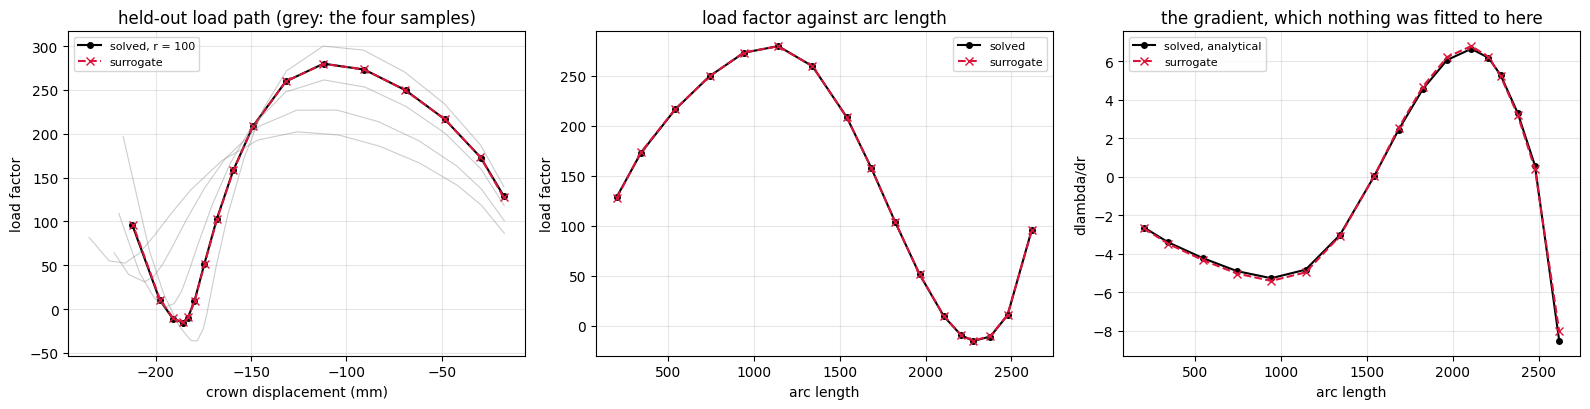

In [10]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16, 4.2))

a1.plot(Check['u'][Inside], Check['lam'][Inside], 'o-', color='k', ms=4,
        label=f'solved, r = {HeldOut:.0f}')
a1.plot(UHat, LamHat, 'x--', color='crimson', ms=6, label='surrogate')
for Radius, Path in Paths.items():
    a1.plot(Path['u'], Path['lam'], '-', lw=0.8, alpha=0.4, color='grey')
a1.set(xlabel='crown displacement (mm)', ylabel='load factor',
       title=f'held-out load path (grey: the four samples)')

a2.plot(Check['s'][Inside], Check['lam'][Inside], 'o-', color='k', ms=4, label='solved')
a2.plot(Check['s'][Inside], LamHat, 'x--', color='crimson', ms=6, label='surrogate')
a2.set(xlabel='arc length', ylabel='load factor', title='load factor against arc length')

a3.plot(Check['s'][Inside], Check['dLamdx'][Inside, 0], 'o-', color='k', ms=4,
        label='solved, analytical')
a3.plot(Check['s'][Inside], dLamHatdx[:, 0], 'x--', color='crimson', ms=6, label='surrogate')
a3.set(xlabel='arc length', ylabel='dlambda/dr',
       title='the gradient, which nothing was fitted to here')

for Axis in (a1, a2, a3):
    Axis.legend(fontsize=8)
    Axis.grid(alpha=0.3)
plt.tight_layout()

## 6. Three variables, fifteen curves

The same construction with a three-radius arch, which is four inputs once arc length is
included and so cannot be drawn as a surface at all. Accuracy is shown instead by holding
designs back and laying the predicted load path over the solved one.

Two things change at this size.

**The design box widens back out to [88, 116].** Three radii through a five-point spline move
far less of the arch each than a single radius did, and the response is correspondingly
tamer - the peak load factor spans 1.5x across the box against 2.4x on the paper's [80, 120]
and 3.8x for one variable. Isolated designs still refuse to trace, about one draw in fifteen,
so the design of experiments is oversized and the first fifteen that solve are kept.

**The basis functions get their own locations, and their own count.** The default puts one
centre at every sample, which makes the function-value system square and interpolating — and
hands the basis exactly the anisotropy the samples have: centres strung along the paths, packed
together in arc length and sparse across designs, so neighbouring centres look nearly identical
to one another. Drawing a smaller space-filling set separates *where the response was sampled*
from *where it is represented*.

That makes the count a hyperparameter, and `ge_rbf.basis_search` chooses it together with the
shape parameter, since the two interact. It holds out **whole designs** to do so, and the
reason is structural rather than fussy: a gradient-enhanced model carries the sampled gradients
as rows of its own fitting system, so it reproduces them better the more centres it is given.
Scored that way the error falls monotonically with the count and can only ever pick the largest
option on offer — so the signal that chooses `epsilon` so well cannot choose a centre count at
all. Holding out folds of *rows* has the same weakness in milder form, because a held-out
point's nearest neighbours are still in the training set; holding out whole trajectories does
not.

The four designs used to report accuracy below are separate again, and no search saw them.

In [11]:
from scipy.stats import qmc

Wanted = 15

Draw = qmc.LatinHypercube(d=3, seed=2).random(20)*(116.0 - 88.0) + 88.0

Paths3, Skipped3 = {}, []
Clock = time.perf_counter()

for Radii in Draw:
    if len(Paths3) == Wanted:
        break
    try:
        Paths3[tuple(Radii)] = Curve(Radii)
    except RuntimeError:
        Skipped3.append(Radii)

Elapsed3 = time.perf_counter() - Clock

X3 = np.concatenate([np.repeat(np.array(Radii)[None, :], Path['s'].size, axis=0)
                     for Radii, Path in Paths3.items()])
S3 = np.concatenate([Path['s'] for Path in Paths3.values()])
G3 = np.concatenate([np.full(Path['s'].size, i)
                     for i, Path in enumerate(Paths3.values())])
Lam3 = np.concatenate([Path['lam'] for Path in Paths3.values()])
dLam3dx = np.concatenate([Path['dLamdx'] for Path in Paths3.values()])
dLam3ds = np.concatenate([Path['dLamds'] for Path in Paths3.values()])
U3 = np.concatenate([Path['u'] for Path in Paths3.values()])
dU3dx = np.concatenate([Path['dUdx'] for Path in Paths3.values()])
dU3ds = np.concatenate([Path['dUds'] for Path in Paths3.values()])

print(f'{len(Paths3)} designs traced, {len(Skipped3)} could not be, {Elapsed3/60:.1f} min')
print(f'{X3.shape[0]} sample rows, {X3.shape[1]} shape variables, '
      f'{X3.shape[1] + 1} inputs counting arc length')
print(f'peak load factor {min(P["lam"].max() for P in Paths3.values()):.0f} to '
      f'{max(P["lam"].max() for P in Paths3.values()):.0f}')
print(f'unit speed holds to {max(np.max(np.abs(P["Speed"] - 1)) for P in Paths3.values()):.1e}')

15 designs traced, 0 could not be, 7.7 min
272 sample rows, 3 shape variables, 4 inputs counting arc length
peak load factor 218 to 523
unit speed holds to 5.6e-16


In [12]:
# Four designs kept back entirely, drawn from the interior so the surrogate is interpolating.
Held = qmc.LatinHypercube(d=3, seed=7).random(6)*(112.0 - 92.0) + 92.0

Checks = {}
for Radii in Held:
    if len(Checks) == 4:
        break
    try:
        Checks[tuple(Radii)] = Curve(Radii)
    except RuntimeError:
        pass

Reach3 = min(Path['s'][-1] for Path in Paths3.values())
print(f'{len(Checks)} held-out designs solved, none of them used to fit anything')
print(f'surrogate is trusted out to arc length {Reach3:.0f}, the shortest sampled path')

4 held-out designs solved, none of them used to fit anything
surrogate is trusted out to arc length 2607, the shortest sampled path


In [13]:
def Accuracy(Model, Key):
    '''Largest error over every held-out design, relative to the response's own range.'''
    Worst = 0.0
    for Radii, Path in Checks.items():
        Inside = Path['s'] <= Reach3
        Predicted = Model.Predict(np.array(Radii)[None, :], Path['s'][Inside])
        Worst = max(Worst, np.max(np.abs(Predicted - Path[Key][Inside]))/np.ptp(Path[Key]))
    return Worst


print(f"{'centres':<22}{'count':>7}{'condition':>12}{'lambda err':>12}{'u err':>9}{'fit':>8}")

Trials = {}
for Name, Setting in (('one per sample', None), ('fixed, 100', 100), ('searched', 'search')):

    Clock = time.perf_counter()
    LamTrial = PathSurrogate(Centres=Setting).Fit(X3, S3, Lam3, dLam3dx, dLam3ds, Groups=G3)
    UTrial = PathSurrogate(Centres=Setting).Fit(X3, S3, U3, dU3dx, dU3ds, Groups=G3)
    Took = time.perf_counter() - Clock

    Trials[Name] = (LamTrial, UTrial)
    print(f'{Name:<22}{LamTrial.Model_.centers_.shape[0]:>7}'
          f'{LamTrial.Model_.condition_:>12.2e}'
          f'{Accuracy(LamTrial, "lam"):>11.2%}{Accuracy(UTrial, "u"):>9.2%}{Took:>7.1f}s')

print()
print(f'errors are the largest over {len(Checks)} unseen designs, relative to each range,')
print('and no search ever saw those designs. The count chosen by basis_search is picked')
print('from held-out FOLDS of the training paths, not from this table.')

Lam3Model, U3Model = Trials['searched']
print()
print(f'load factor:  {Lam3Model.Search_.best_n_centers} centres, '
      f'epsilon {Lam3Model.Search_.best_epsilon:.4g}, '
      f'{Lam3Model.Search_.rejected} of '
      f'{Lam3Model.Search_.scores.size} cells rejected on conditioning')
print(f'displacement: {U3Model.Search_.best_n_centers} centres, '
      f'epsilon {U3Model.Search_.best_epsilon:.4g}')

centres                 count   condition  lambda err    u err     fit


one per sample            272    9.75e+12      8.27%   26.57%    6.3s


fixed, 100                100    5.87e+09      5.12%    0.29%    1.1s


searched                  136    6.49e+12      5.68%    0.38%   20.3s

errors are the largest over 4 unseen designs, relative to each range,
and no search ever saw those designs. The count chosen by basis_search is picked
from held-out FOLDS of the training paths, not from this table.

load factor:  136 centres, epsilon 0.000154, 22 of 400 cells rejected on conditioning
displacement: 85 centres, epsilon 0.007689


grey: the 15 solved paths the models were fitted to.
Every black dashed curve is a design the solver was never run at during fitting.


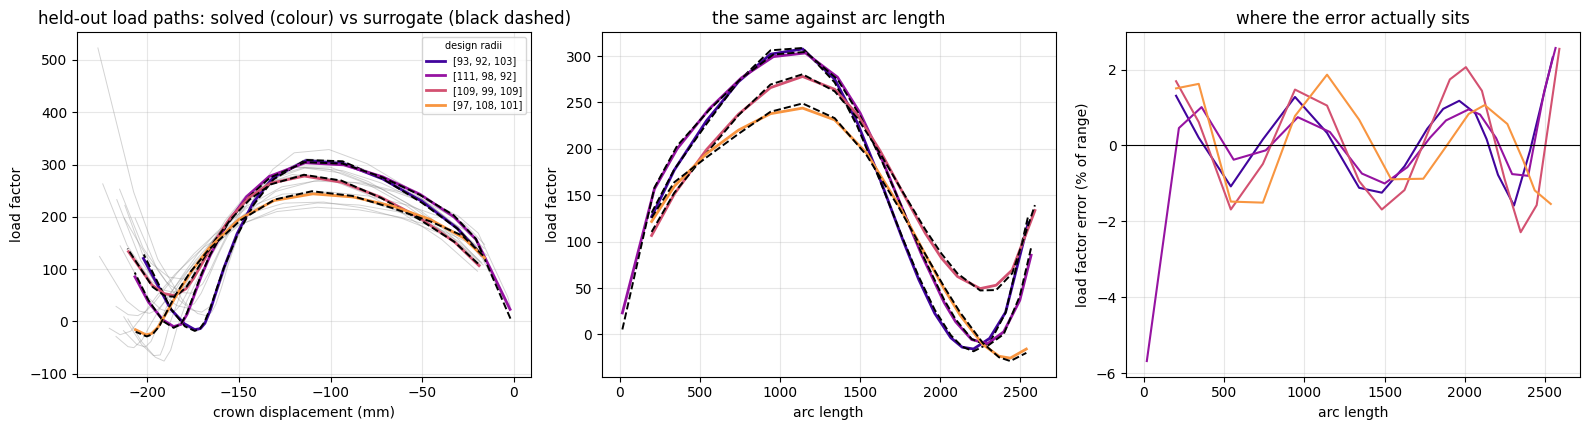

In [14]:
fig, Axes = plt.subplots(1, 3, figsize=(16, 4.4))
a1, a2, a3 = Axes

Shades = plt.cm.plasma(np.linspace(0.1, 0.75, len(Checks)))

# The fifteen training paths, faint, for context.
for Path in Paths3.values():
    a1.plot(Path['u'], Path['lam'], '-', lw=0.7, alpha=0.35, color='grey')

for Colour, (Radii, Path) in zip(Shades, Checks.items(), strict=True):
    Inside = Path['s'] <= Reach3
    LamHat3 = Lam3Model.Predict(np.array(Radii)[None, :], Path['s'][Inside])
    UHat3 = U3Model.Predict(np.array(Radii)[None, :], Path['s'][Inside])

    Label = f'[{Radii[0]:.0f}, {Radii[1]:.0f}, {Radii[2]:.0f}]'
    a1.plot(Path['u'][Inside], Path['lam'][Inside], '-', lw=2, color=Colour, label=Label)
    a1.plot(UHat3, LamHat3, '--', lw=1.4, color='k')

    a2.plot(Path['s'][Inside], Path['lam'][Inside], '-', lw=2, color=Colour)
    a2.plot(Path['s'][Inside], LamHat3, '--', lw=1.4, color='k')

    a3.plot(Path['s'][Inside],
            (LamHat3 - Path['lam'][Inside])/np.ptp(Path['lam'])*100, '-', color=Colour)

a1.set(xlabel='crown displacement (mm)', ylabel='load factor',
       title='held-out load paths: solved (colour) vs surrogate (black dashed)')
a1.legend(fontsize=7, title='design radii', title_fontsize=7)

a2.set(xlabel='arc length', ylabel='load factor', title='the same against arc length')

a3.axhline(0, color='k', lw=0.8)
a3.set(xlabel='arc length', ylabel='load factor error (% of range)',
       title='where the error actually sits')

for Axis in Axes:
    Axis.grid(alpha=0.3)
plt.tight_layout()

print(f'grey: the {len(Paths3)} solved paths the models were fitted to.')
print('Every black dashed curve is a design the solver was never run at during fitting.')

## What this is for

Two responses fitted from solved load paths and agreeing with designs none of them saw: four
solves and one check at one variable, fifteen and four at three.

An objective is now a calculation on top of them. Matching a target load path means evaluating
both surfaces at the target's own arc lengths and summing a squared difference, which costs
microseconds and no simulations - and, being a function of fixed arc lengths rather than of
whichever arc lengths the solver happened to choose, it is smooth in the design variables in a
way the directly-computed objective is not. That is what
[`ArcLengthControlledShapeDesign.ipynb`](ArcLengthControlledShapeDesign.ipynb) section 5 runs
aground on, where SLSQP stops 10.7 mm from a known optimum because the objective jumps whenever
the arc step count changes.

Building that objective, and optimising over it, is the next step and is deliberately not here.
What had to be true first is on this page: the arc-length derivatives exist and are right, the
scaling makes the coordinate frame estimable, and the surfaces reproduce a design they never
saw.